# TUANDROMD ML 

## 0) Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, SelectKBest
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110


## 1) Matplotlib Functions

In [2]:
def save_current_fig(name: str, dpi: int = 300):
    fig_dir = Path("figures")
    fig_dir.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(fig_dir / name, dpi=dpi, bbox_inches="tight")

def plot_class_distribution(y, class_names=None, title='Class Distribution'):
    labels, counts = np.unique(y, return_counts=True)

    plt.figure(figsize=(7, 5))
    plt.bar(labels.astype(str), counts, edgecolor='black', linewidth=0.6)
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Number of Samples')

    if class_names is not None and len(class_names) == len(labels):
        plt.xticks(ticks=labels, labels=class_names)
    else:
        plt.xticks(ticks=labels, labels=[str(x) for x in labels])

    plt.tight_layout()
    save_current_fig("plot_class_distribution.png")
    plt.show()


def plot_horizontal_bar(values, names, title, xlabel, ylabel, sort=True):
    values = np.asarray(values).ravel()
    names = list(names)

    if sort:
        order = np.argsort(values)
        values = values[order]
        names = [names[i] for i in order]

    plt.figure(figsize=(12, 8))
    plt.barh(names, values, edgecolor='black', linewidth=0.4)
    plt.title(title, fontsize=14, pad=20)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12, labelpad=15)
    plt.tight_layout()
    plt.subplots_adjust(left=0.30)
    save_current_fig("plot_horizontal_bar.png")
    plt.show()


def plot_grouped_count_by_hue(x, y, ax, title, xlabel, hue_title='Class', class_names=None):
    x = np.asarray(x)
    y = np.asarray(y)

    x_levels = np.unique(x)
    y_levels = np.unique(y)

    count_mat = np.zeros((len(x_levels), len(y_levels)), dtype=int)
    for xi, xv in enumerate(x_levels):
        for yi, yv in enumerate(y_levels):
            count_mat[xi, yi] = np.sum((x == xv) & (y == yv))

    indices = np.arange(len(x_levels))
    total_hues = len(y_levels)
    width = 0.8 / max(total_hues, 1)

    for j, yv in enumerate(y_levels):
        ax.bar(
            indices + (j - (total_hues - 1) / 2) * width,
            count_mat[:, j],
            width=width,
            edgecolor='black',
            linewidth=0.3,
            label=(class_names[j] if class_names is not None else str(yv))
        )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.set_xticks(indices)
    ax.set_xticklabels([str(v) for v in x_levels])
    ax.legend(title=hue_title, fontsize=9)


def plot_correlation_heatmap(corr_df, mask_upper=True, title='Correlation Heatmap'):
    cm = corr_df.values.astype(float)
    n = cm.shape[0]

    if mask_upper:
        mask = np.triu(np.ones_like(cm, dtype=bool))
        cm_plot = cm.copy()
        cm_plot[mask] = np.nan
    else:
        cm_plot = cm

    plt.figure(figsize=(16, 12))
    im = plt.imshow(cm_plot, cmap='coolwarm', vmin=-1, vmax=1)
    plt.gca().set_aspect('equal')

    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=9)

    labels = list(corr_df.columns)
    plt.xticks(range(n), labels, rotation=45, ha='right', fontsize=10)
    plt.yticks(range(n), labels, rotation=0, fontsize=10)

    plt.gca().set_xticks(np.arange(-.5, n, 1), minor=True)
    plt.gca().set_yticks(np.arange(-.5, n, 1), minor=True)
    plt.grid(which='minor', color='white', linestyle='-', linewidth=0.5)
    plt.tick_params(which='minor', bottom=False, left=False)

    for r in range(n):
        for c in range(n):
            if np.isnan(cm_plot[r, c]):
                continue
            plt.text(c, r, f'{cm_plot[r, c]:.2f}', ha='center', va='center', fontsize=8)

    plt.title(title, fontsize=16, pad=25)
    plt.subplots_adjust(left=0.15, bottom=0.25)
    save_current_fig("plot_correlation_heatmap.png")
    plt.show()


def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar(fraction=0.046, pad=0.04)

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=0)
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=10
            )

    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    save_current_fig("plot_confusion_matrix.png")
    plt.show()


## 2) Data Upload and Fast EDA

In [3]:
DATA_PATH = Path.cwd() / "TUANDROMD.csv"
df = pd.read_csv(DATA_PATH)

print(f'Gözlem Sayısı: {df.shape[0]}')
print(f'\nÖzellik Sayısı: {df.shape[1]}\n')
print(df.info())

print('\nİlk 5 Satır')
print(df.head())

print('\nİstatistiksel Özet (ilk 20 satır)')
print(df.describe().T.head(20))

print('\nSütun Bazında Benzersiz Değer Sayıları (İlk 10)')
print(df.nunique().head(10))

print('\nLabel Dağılımı')
counts = df['Label'].value_counts()
percentages = df['Label'].value_counts(normalize=True) * 100
for label, count in counts.items():
    print(f'{label}: {count} örnek ({percentages[label]:.2f}%)')

missing_values = df.isnull().sum().sum()
print(f'Toplam Eksik Değer: {missing_values}')

_df_before = df.shape[0]
df.dropna(inplace=True)
print(f'Eksik değer temizliği: {_df_before} -> {df.shape[0]} satır')


Gözlem Sayısı: 4465

Özellik Sayısı: 242

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4465 entries, 0 to 4464
Columns: 242 entries, ACCESS_ALL_DOWNLOADS to Label
dtypes: float64(241), object(1)
memory usage: 8.2+ MB
None

İlk 5 Satır
   ACCESS_ALL_DOWNLOADS  ACCESS_CACHE_FILESYSTEM  ACCESS_CHECKIN_PROPERTIES  \
0                   0.0                      0.0                        0.0   
1                   0.0                      0.0                        0.0   
2                   0.0                      0.0                        0.0   
3                   0.0                      0.0                        0.0   
4                   0.0                      0.0                        0.0   

   ACCESS_COARSE_LOCATION  ACCESS_COARSE_UPDATES  ACCESS_FINE_LOCATION  \
0                     0.0                    0.0                   0.0   
1                     0.0                    0.0                   0.0   
2                     0.0                    0.0               

## 3) Label Encoding + Train/Test Split

Class Matches: {'goodware': np.int64(0), 'malware': np.int64(1)}
Training Set: 3571 samples
Test Set: 893 samples


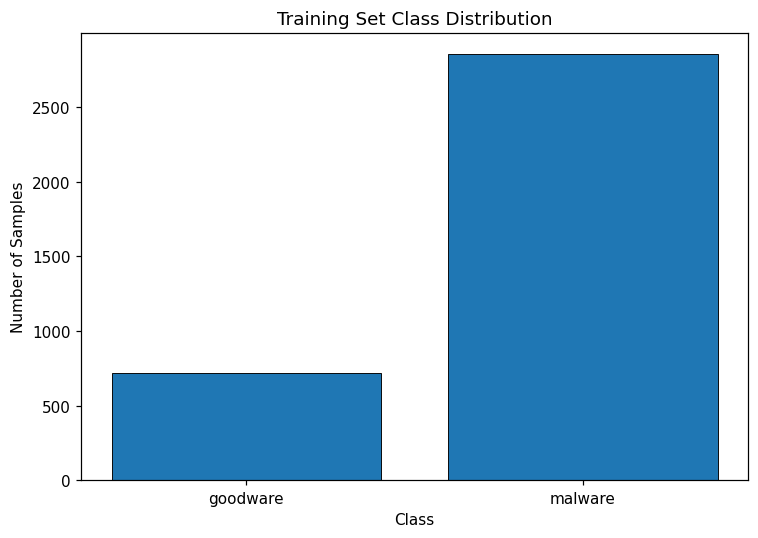

In [4]:
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f'Class Matches: {mapping}')

X = df.drop('Label', axis=1)
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training Set: {X_train.shape[0]} samples')
print(f'Test Set: {X_test.shape[0]} samples')

plot_class_distribution(y_train, class_names=list(le.classes_), title='Training Set Class Distribution')

## 4) Transformers for Pipeline

In [5]:
class VarianceThresholdDF(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.01):
        self.threshold = threshold
        self.selector_ = VarianceThreshold(threshold=self.threshold)
        self.kept_cols_ = None

    def fit(self, X, y=None):
        self.selector_.fit(X)
        self.kept_cols_ = list(X.columns[self.selector_.get_support()])
        return self

    def transform(self, X):
        return X[self.kept_cols_].copy()


class CorrelationFilterDF(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.to_drop_ = None
        self.kept_cols_ = None

    def fit(self, X, y=None):
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.to_drop_ = [col for col in upper.columns if any(upper[col] > self.threshold)]
        self.kept_cols_ = [c for c in X.columns if c not in self.to_drop_]
        return self

    def transform(self, X):
        return X[self.kept_cols_].copy()


class SelectKBestMIDF(BaseEstimator, TransformerMixin):
    def __init__(self, k=60, random_state=42):
        self.k = k
        self.random_state = random_state
        self.selector_ = None
        self.selected_cols_ = None
        self.scores_ = None

    def fit(self, X, y):
        def mi_score_func(X_arr, y_arr):
            return mutual_info_classif(X_arr, y_arr, random_state=self.random_state)

        self.selector_ = SelectKBest(score_func=mi_score_func, k=self.k)
        self.selector_.fit(X.values, y)

        support = self.selector_.get_support()
        self.selected_cols_ = list(X.columns[support])

        # tüm kolonlara ait skorları sakla
        self.scores_ = pd.Series(self.selector_.scores_, index=X.columns).sort_values(ascending=False)
        return self

    def transform(self, X):
        return X[self.selected_cols_].copy()


class StandardScalerDF(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.scaler_ = StandardScaler()
        self.cols_ = None

    def fit(self, X, y=None):
        self.cols_ = list(X.columns)
        self.scaler_.fit(X.values)
        return self

    def transform(self, X):
        arr = self.scaler_.transform(X.values)
        return pd.DataFrame(arr, columns=self.cols_, index=X.index)


def get_selected_feature_names(fitted_pipeline: Pipeline):
    if 'select' in fitted_pipeline.named_steps:
        return fitted_pipeline.named_steps['select'].selected_cols_
    if 'corr' in fitted_pipeline.named_steps:
        return fitted_pipeline.named_steps['corr'].kept_cols_
    if 'var' in fitted_pipeline.named_steps:
        return fitted_pipeline.named_steps['var'].kept_cols_
    return None


## 5) Evaluation

In [6]:
def get_score_vector(model, X):

    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, 1]
        return proba.ravel()

    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X)
        return np.asarray(scores).ravel()

    return None


def evaluate_model(model, X_test, y_test, model_name, class_names, plot_curves=True):
    y_pred = model.predict(X_test)

    print(f' {model_name} Scores')
    print(classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(class_names)))
    plot_confusion_matrix(cm, class_names=class_names, title=f'{model_name} - Confusion Matrix')

    test_f1 = f1_score(y_test, y_pred, average='weighted')
    test_acc = accuracy_score(y_test, y_pred)

    score_vec = get_score_vector(model, X_test)

    roc_auc = None
    pr_auc = None

    is_binary = (len(np.unique(y_test)) == 2)
    if is_binary and score_vec is not None:
        roc_auc = roc_auc_score(y_test, score_vec)
        pr_auc = average_precision_score(y_test, score_vec)

        print(f'ROC-AUC: {roc_auc:.4f}')
        print(f'PR-AUC (Average Precision): {pr_auc:.4f}')

        if plot_curves:
            fpr, tpr, _ = roc_curve(y_test, score_vec)
            plt.figure(figsize=(6, 5))
            plt.plot(fpr, tpr)
            plt.plot([0, 1], [0, 1], linestyle='--')
            plt.title(f'{model_name} - ROC Curve (AUC={roc_auc:.3f})')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.tight_layout()
            save_current_fig("roc.png")
            plt.show()

            precision, recall, _ = precision_recall_curve(y_test, score_vec)
            plt.figure(figsize=(6, 5))
            plt.plot(recall, precision)
            plt.title(f'{model_name} - Precision-Recall Curve (AP={pr_auc:.3f})')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.tight_layout()
            save_current_fig("pr_curve.png")
            plt.show()
    else:
        if not is_binary:
            print('ROC-AUC / PR-AUC: Multi-class için ek uyarlama gerekir')
        elif score_vec is None:
            print('ROC-AUC / PR-AUC: Model continuous skor üretmedi')

    return {
        'f1_weighted': test_f1,
        'accuracy': test_acc,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
    }


## 6) Baseline + Model Pipelines + GridSearchCV

1) Baseline (Dummy) Model is being evaluated.
 Baseline (Dummy) Model Scores
              precision    recall  f1-score   support

    goodware       0.00      0.00      0.00       180
     malware       0.80      1.00      0.89       713

    accuracy                           0.80       893
   macro avg       0.40      0.50      0.44       893
weighted avg       0.64      0.80      0.71       893



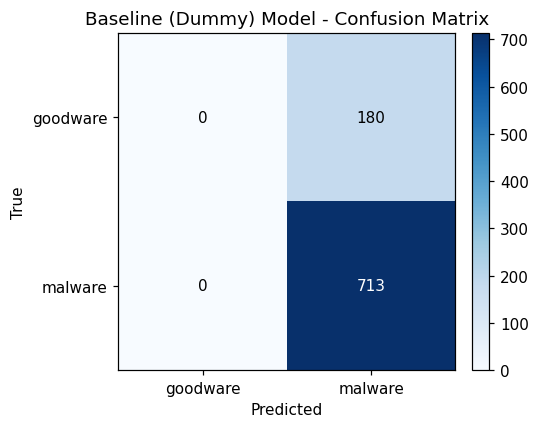

ROC-AUC: 0.5000
PR-AUC (Average Precision): 0.7984
2) The Training and Optimization Process Has Begun.
Logistic Regression Being Optimized
 Logistic Regression Scores
              precision    recall  f1-score   support

    goodware       0.99      0.94      0.97       180
     malware       0.99      1.00      0.99       713

    accuracy                           0.99       893
   macro avg       0.99      0.97      0.98       893
weighted avg       0.99      0.99      0.99       893



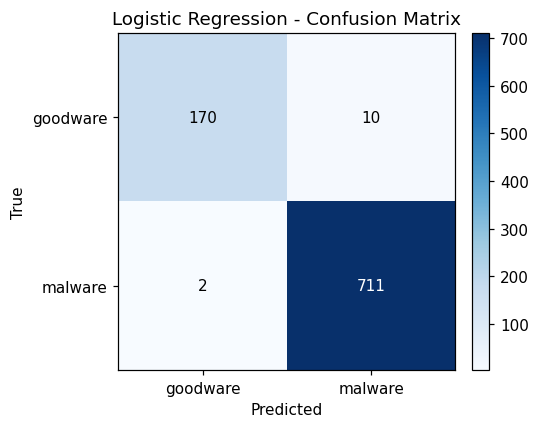

ROC-AUC: 0.9919
PR-AUC (Average Precision): 0.9966
[Logistic Regression] Selected feature count: 57
Random Forest Being Optimized
 Random Forest Scores
              precision    recall  f1-score   support

    goodware       1.00      0.99      0.99       180
     malware       1.00      1.00      1.00       713

    accuracy                           1.00       893
   macro avg       1.00      0.99      1.00       893
weighted avg       1.00      1.00      1.00       893



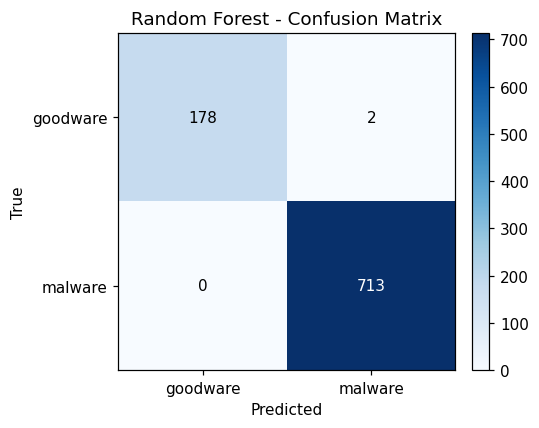

ROC-AUC: 1.0000
PR-AUC (Average Precision): 1.0000
[Random Forest] Selected feature count: 60
HistGradientBoosting Being Optimized
 HistGradientBoosting Scores
              precision    recall  f1-score   support

    goodware       1.00      0.99      0.99       180
     malware       1.00      1.00      1.00       713

    accuracy                           1.00       893
   macro avg       1.00      0.99      1.00       893
weighted avg       1.00      1.00      1.00       893



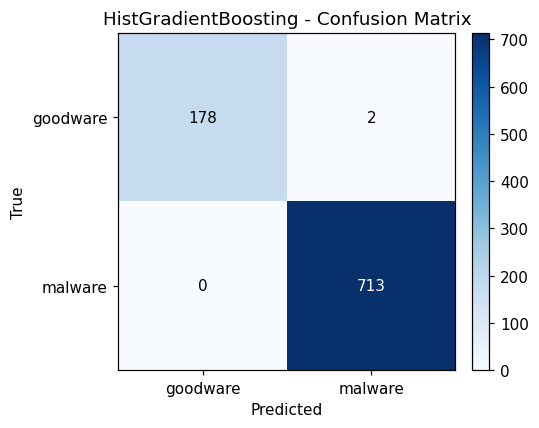

ROC-AUC: 1.0000
PR-AUC (Average Precision): 1.0000
[HistGradientBoosting] Selected feature count: 57


,Model,Best CV F1,Test F1,Test Accuracy,Test ROC-AUC,Test PR-AUC,Best Params
2,Random Forest,0.991897,0.997756,0.997760,0.999984,0.999996,"{'corr__threshold': 0.9, 'model__class_weight'..."
3,HistGradientBoosting,0.991597,0.997756,0.997760,0.999969,0.999992,"{'corr__threshold': 0.85, 'model__learning_rat..."
1,Logistic Regression,0.985671,0.986447,0.986562,0.991912,0.996555,"{'corr__threshold': 0.85, 'model__C': 10, 'mod..."
0,Baseline (Dummy),-,0.708944,0.798432,0.500000,0.798432,N/A


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('1) Baseline (Dummy) Model is being evaluated.')
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)

metrics_dummy = evaluate_model(
    dummy_clf, X_test, y_test,
    model_name='Baseline (Dummy) Model',
    class_names=list(le.classes_),
    plot_curves=False
)

comparison_table = [{
    'Model': 'Baseline (Dummy)',
    'Best CV F1': '-',
    'Test F1': metrics_dummy['f1_weighted'],
    'Test Accuracy': metrics_dummy['accuracy'],
    'Test ROC-AUC': metrics_dummy['roc_auc'],
    'Test PR-AUC': metrics_dummy['pr_auc'],
    'Best Params': 'N/A'
}]

best_models = {}

preprocess_common = [
    ('var', VarianceThresholdDF(threshold=0.01)),
    ('corr', CorrelationFilterDF(threshold=0.9)),
    ('select', SelectKBestMIDF(k=60, random_state=42)),
]

lr_pipeline = Pipeline(steps=[
    *preprocess_common,
    ('scaler', StandardScalerDF()),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

rf_pipeline = Pipeline(steps=[
    *preprocess_common,
    ('model', RandomForestClassifier(random_state=42))
])

hgb_pipeline = Pipeline(steps=[
    *preprocess_common,
    ('model', HistGradientBoostingClassifier(random_state=42))
])

model_pipeline = {
    'Logistic Regression': {
        'pipeline': lr_pipeline,
        'params': {
            'select__k': [20, 60, 100],
            'corr__threshold': [0.85, 0.9, 0.95],
            'model__C': [0.1, 1, 10],
            'model__penalty': ['l2'],
            'model__class_weight': [None, 'balanced'],
        }
    },
    'Random Forest': {
        'pipeline': rf_pipeline,
        'params': {
            'select__k': [20, 60, 100],
            'corr__threshold': [0.85, 0.9, 0.95],
            'model__n_estimators': [200, 500],
            'model__max_depth': [None, 10, 20],
            'model__class_weight': [None, 'balanced'],
        }
    },
    'HistGradientBoosting': {
        'pipeline': hgb_pipeline,
        'params': {
            'select__k': [20, 60, 100],
            'corr__threshold': [0.85, 0.9, 0.95],
            'model__learning_rate': [0.03, 0.1],
            'model__max_depth': [3, 6, None],
            'model__max_iter': [200, 500],
            'model__min_samples_leaf': [10, 30],
        }
    }
}

print('2) The Training and Optimization Process Has Begun.')

for name, config in model_pipeline.items():
    print(f"{name} Being Optimized")

    gs = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['params'],
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1
    )

    gs.fit(X_train, y_train)

    best_model = gs.best_estimator_
    best_models[name] = best_model

    metrics = evaluate_model(
        best_model, X_test, y_test,
        model_name=name,
        class_names=list(le.classes_),
        plot_curves=False
    )

    comparison_table.append({
        'Model': name,
        'Best CV F1': gs.best_score_,
        'Test F1': metrics['f1_weighted'],
        'Test Accuracy': metrics['accuracy'],
        'Test ROC-AUC': metrics['roc_auc'],
        'Test PR-AUC': metrics['pr_auc'],
        'Best Params': gs.best_params_
    })

    selected_cols = get_selected_feature_names(best_model)
    if selected_cols is not None:
        print(f'[{name}] Selected feature count: {len(selected_cols)}')

results_df = pd.DataFrame(comparison_table).sort_values(by='Test F1', ascending=False)
results_df


## 7) Results Summary + F1 Comparison Chart

                  Model   Test F1  Test Accuracy  Test ROC-AUC  Test PR-AUC  \
2         Random Forest  0.997756       0.997760      0.999984     0.999996   
3  HistGradientBoosting  0.997756       0.997760      0.999969     0.999992   
1   Logistic Regression  0.986447       0.986562      0.991912     0.996555   
0      Baseline (Dummy)  0.708944       0.798432      0.500000     0.798432   

  Best CV F1  
2   0.991897  
3   0.991597  
1   0.985671  
0          -  


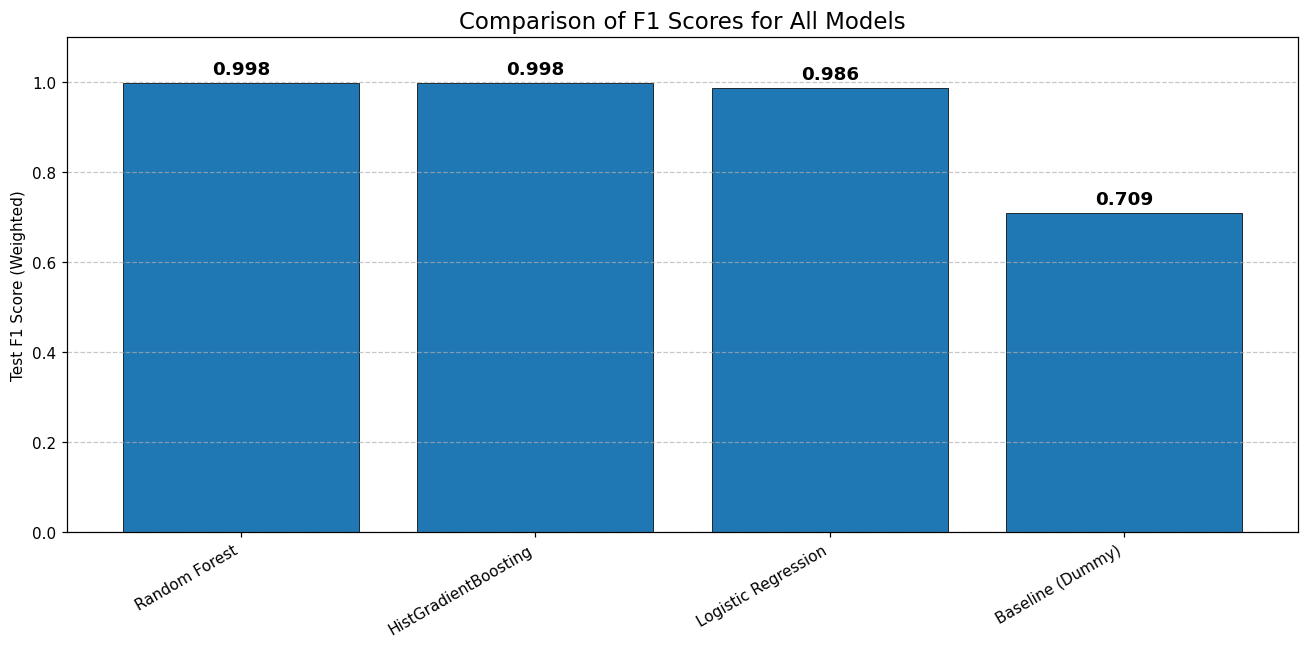

In [8]:
print(results_df[['Model', 'Test F1', 'Test Accuracy', 'Test ROC-AUC', 'Test PR-AUC', 'Best CV F1']])

plt.figure(figsize=(12, 6))
models = results_df['Model'].astype(str).values
scores = results_df['Test F1'].values

plt.bar(models, scores, edgecolor='black', linewidth=0.5)
plt.title('Comparison of F1 Scores for All Models', fontsize=15)
plt.ylabel('Test F1 Score (Weighted)')
plt.ylim(0, 1.1)
plt.xticks(rotation=30, ha='right')

for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
save_current_fig("model_comparison_f1_score.png")
plt.show()


## 8) ROC/PR Curves for the Best Model

 BEST: Random Forest Scores
              precision    recall  f1-score   support

    goodware       1.00      0.99      0.99       180
     malware       1.00      1.00      1.00       713

    accuracy                           1.00       893
   macro avg       1.00      0.99      1.00       893
weighted avg       1.00      1.00      1.00       893



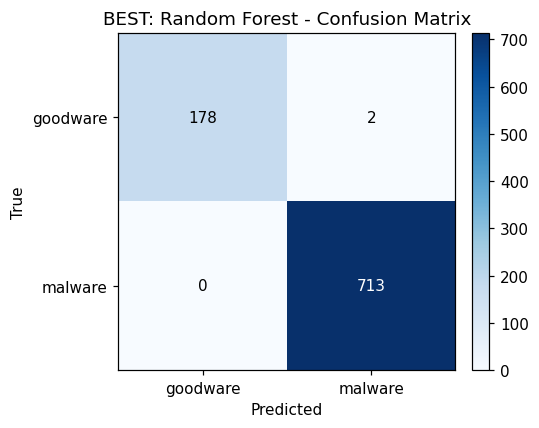

ROC-AUC: 1.0000
PR-AUC (Average Precision): 1.0000


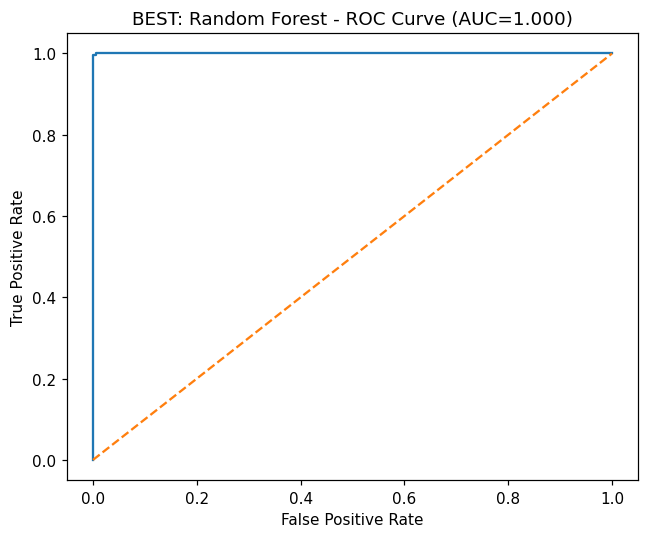

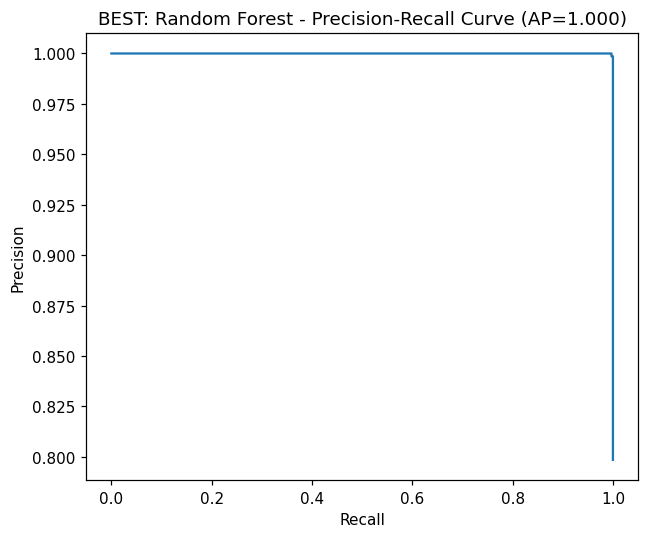

In [9]:
best_name = results_df.iloc[0]['Model']

if best_name in best_models:
    best_pipe = best_models[best_name]
    _ = evaluate_model(
        best_pipe, X_test, y_test,
        model_name=f'BEST: {best_name}',
        class_names=list(le.classes_),
        plot_curves=True
    )


## 9) Feature Visualizations and MI Scores

[VIZ] Best model: Random Forest
[VIZ] Top-2 feature: ['RECEIVE_BOOT_COMPLETED', 'Ljava/net/URL;->openConnection']


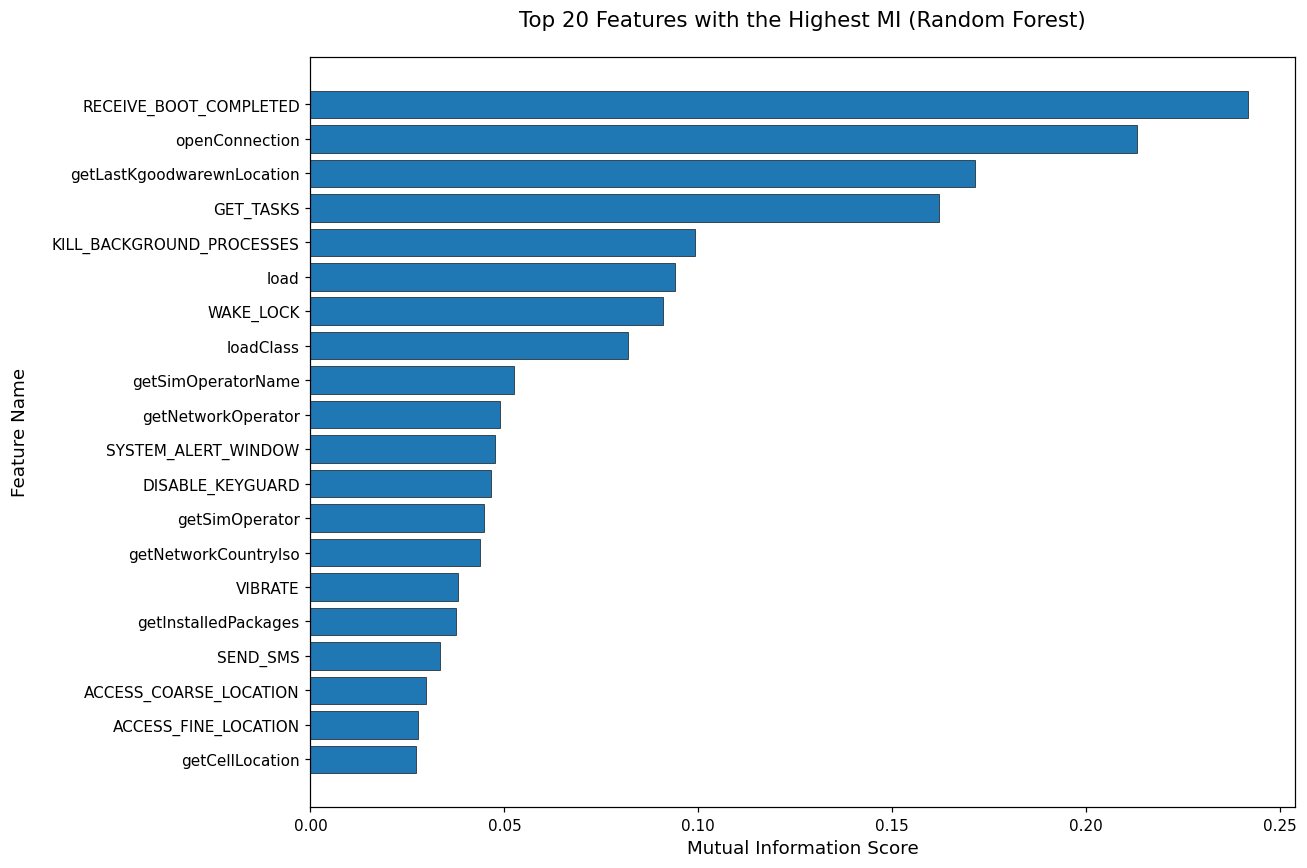

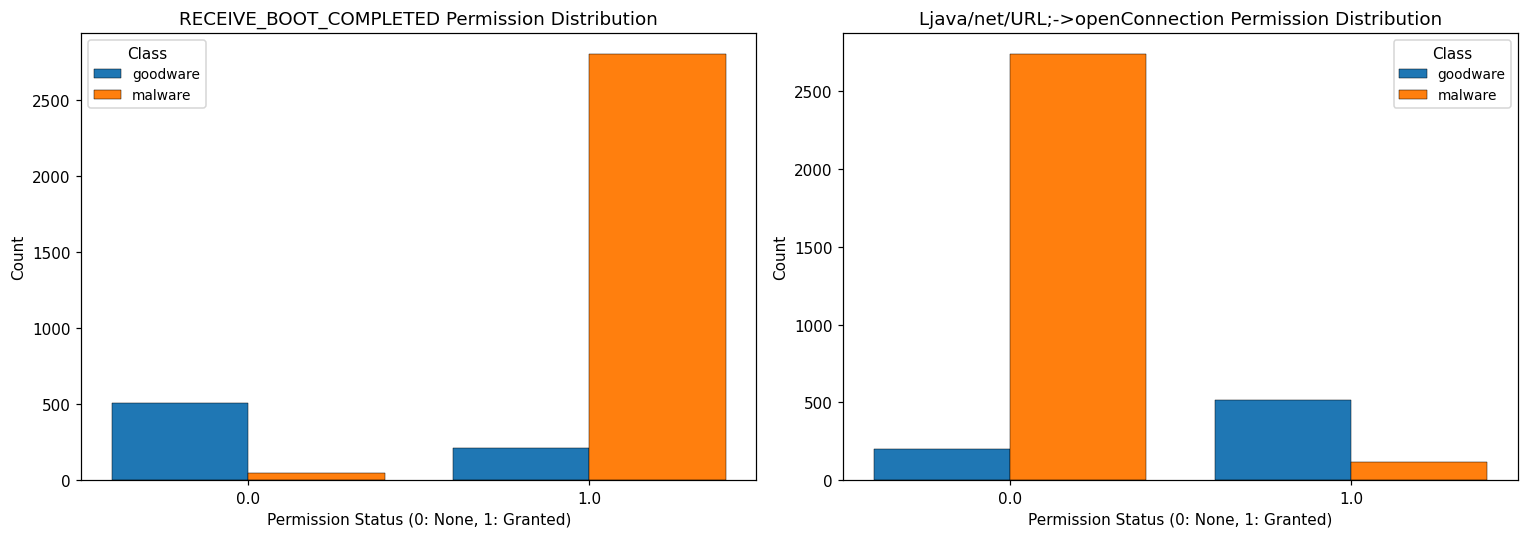

Correlation Heatmap


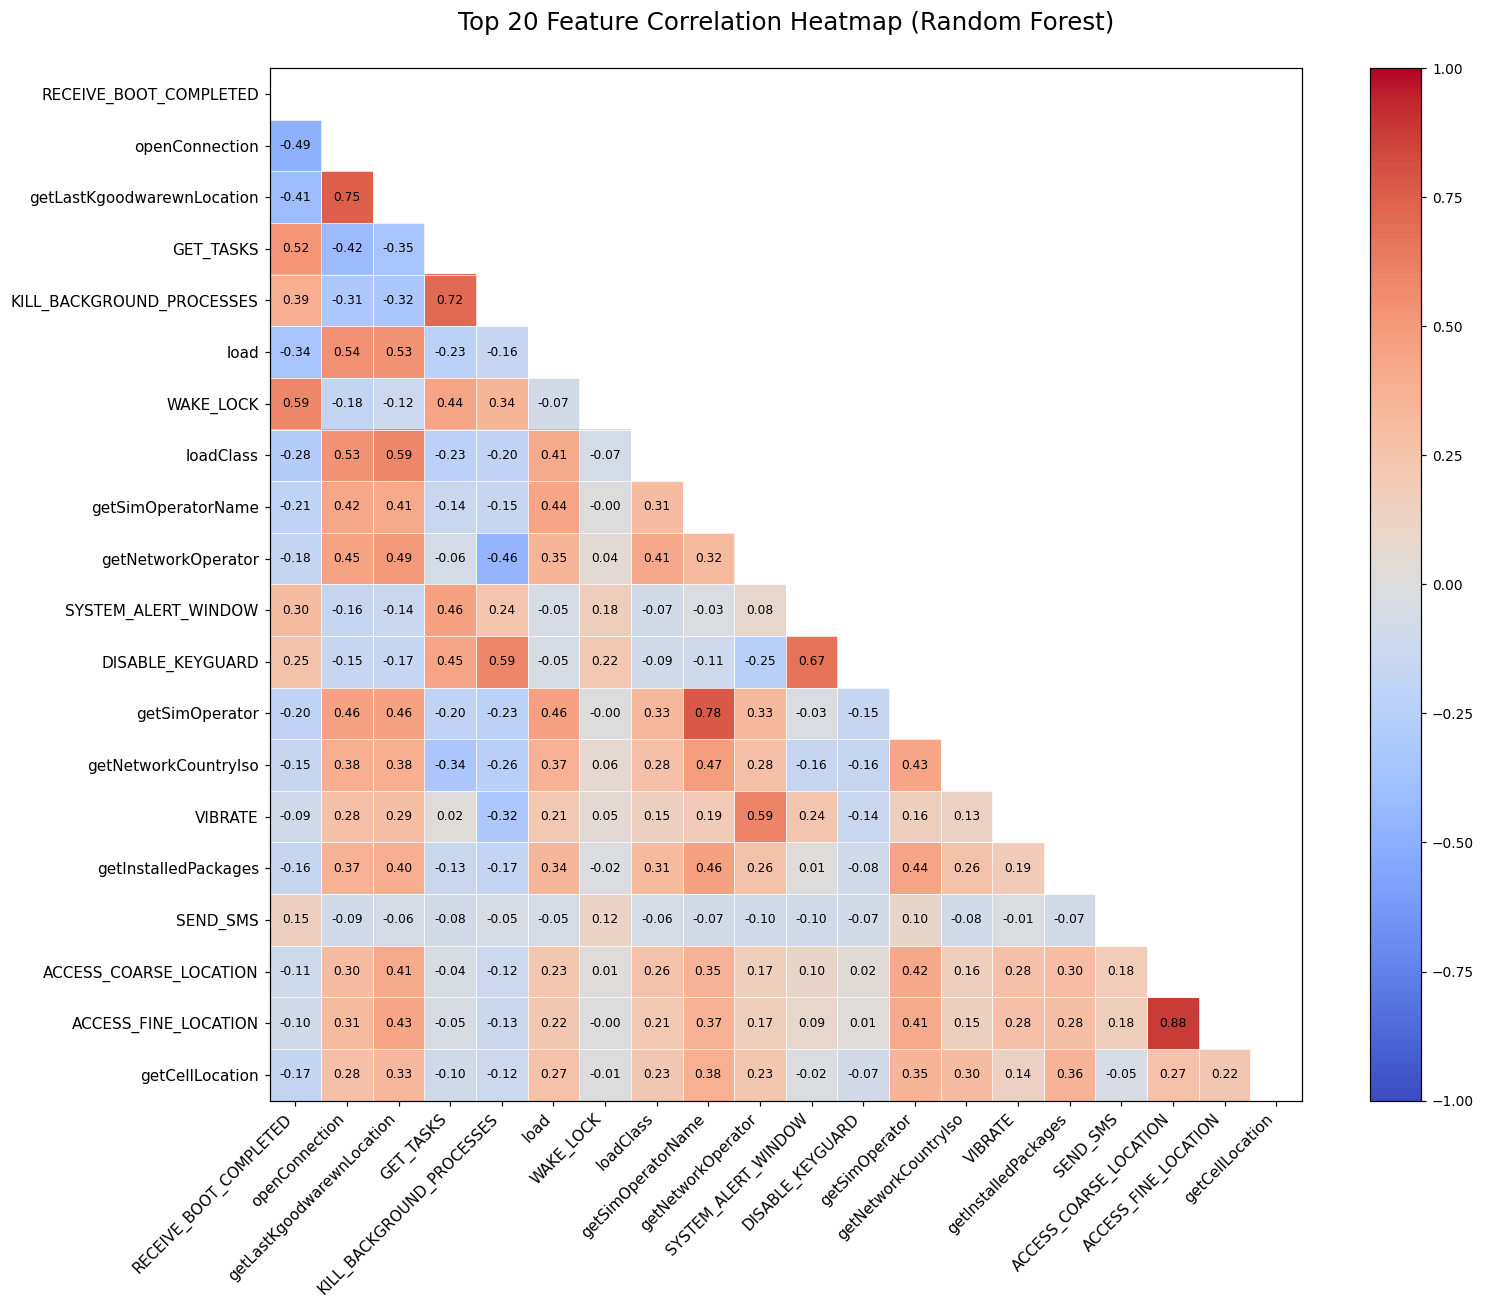

In [10]:
if best_name in best_models:
    pipe_viz = best_models[best_name]

    mi_scores = pipe_viz.named_steps['select'].scores_.sort_values(ascending=False)
    top_20_features = mi_scores.head(20).index.tolist()
    top_2_features = mi_scores.head(2).index.tolist()

    print(f'[VIZ] Best model: {best_name}')
    print(f'[VIZ] Top-2 feature: {top_2_features}')

    X_train_var = pipe_viz.named_steps['var'].transform(X_train)
    X_train_proc = pipe_viz.named_steps['corr'].transform(X_train_var)

    clean_names = [name.split('.')[-1].split('->')[-1] for name in mi_scores.head(20).index]
    plot_horizontal_bar(
        values=mi_scores.head(20).values,
        names=clean_names,
        title=f'Top 20 Features with the Highest MI ({best_name})',
        xlabel='Mutual Information Score',
        ylabel='Feature Name',
        sort=True
        )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    class_names_for_legend = list(le.classes_)

    for i, col in enumerate(top_2_features):
        plot_grouped_count_by_hue(
            x=X_train_proc[col].values,
            y=y_train.values,
            ax=axes[i],
            title=f'{col} Permission Distribution',
            xlabel='Permission Status (0: None, 1: Granted)',
            hue_title='Class',
            class_names=class_names_for_legend
        )

    plt.tight_layout()
    save_current_fig("feature_distribution.png")
    plt.show()

    print('Correlation Heatmap')
    short_names = [name.split('.')[-1].split('->')[-1] for name in top_20_features]

    corr = X_train_proc[top_20_features].corr()
    corr.index = short_names
    corr.columns = short_names

    plot_correlation_heatmap(
        corr,
        mask_upper=True,
        title=f'Top 20 Feature Correlation Heatmap ({best_name})'
    )


## 10) Feature Importance 

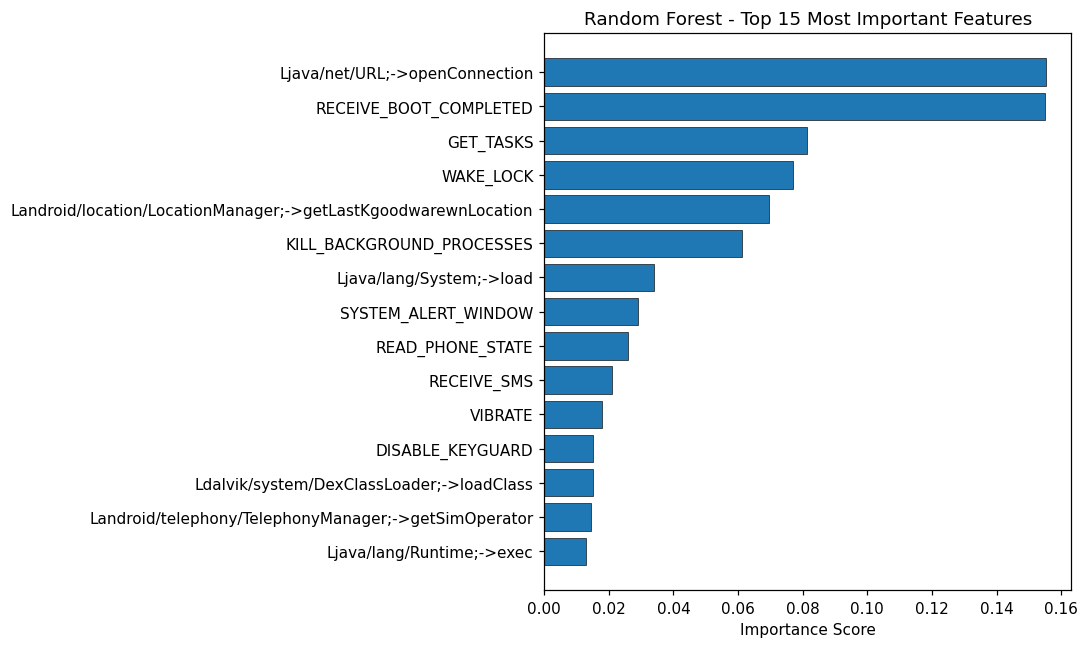

In [11]:
def plot_feature_importance_pipeline(pipeline_model, model_name, X_test, y_test):
    feature_names = get_selected_feature_names(pipeline_model)
    final_est = pipeline_model.named_steps['model']

    if feature_names is None:
        print(f'{model_name}: Feature names could not be retrieved.')
        return

    plt.figure(figsize=(10, 6))

    if hasattr(final_est, 'feature_importances_'):
        feat_importances = pd.Series(final_est.feature_importances_, index=feature_names)
    else:
        perm = permutation_importance(
            pipeline_model, X_test, y_test,
            n_repeats=10, random_state=42,
            scoring='f1_weighted', n_jobs=-1
        )
        feat_importances = pd.Series(perm.importances_mean, index=feature_names)

    top = feat_importances.nlargest(15).sort_values()
    plt.barh(top.index, top.values, edgecolor='black', linewidth=0.4)
    plt.title(f'{model_name} - Top 15 Most Important Features')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    save_current_fig("plot_feature_importance_pipeline.png")
    plt.show()


if best_name in best_models:
    plot_feature_importance_pipeline(best_models[best_name], best_name, X_test, y_test)


## 11) Overfitting Analysis

In [12]:
def check_overfitting(models_dict, X_train, y_train, X_test, y_test):
    print(' OVERFITTING ANALYSIS '.center(40))

    for name, model in models_dict.items():
        train_pred = model.predict(X_train)
        train_f1 = f1_score(y_train, train_pred, average='weighted')

        test_pred = model.predict(X_test)
        test_f1 = f1_score(y_test, test_pred, average='weighted')

        diff = train_f1 - test_f1
        status = 'Overfit Risk!' if diff > 0.1 else 'Healthy'

        print(f'\n[{name}]')
        print(f'  Training F1: {train_f1:.4f}')
        print(f'  Test F1:   {test_f1:.4f}')
        print(f'  Difference:      {diff:.4f} -> {status}')

check_overfitting(best_models, X_train, y_train, X_test, y_test)


          OVERFITTING ANALYSIS          

[Logistic Regression]
  Training F1: 0.9896
  Test F1:   0.9864
  Difference:      0.0032 -> Healthy

[Random Forest]
  Training F1: 0.9964
  Test F1:   0.9978
  Difference:      -0.0014 -> Healthy

[HistGradientBoosting]
  Training F1: 0.9964
  Test F1:   0.9978
  Difference:      -0.0014 -> Healthy
